In [200]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm


from copy import copy
import numpy as np
import matplotlib.pyplot as plt

Lattice(386 vertices, 772 edges) Lattice(399 vertices, 798 edges)


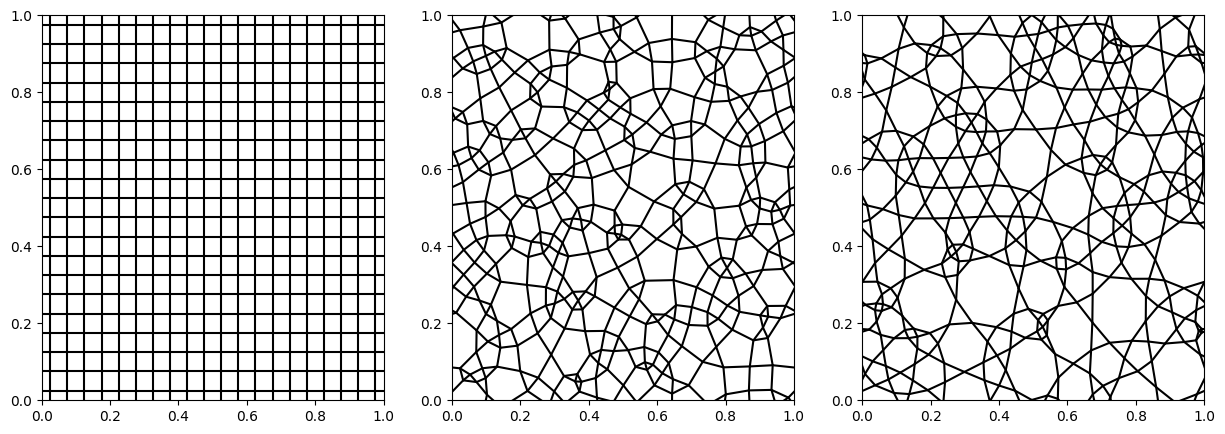

In [201]:
# generate the lattice
n_vertices = 400
points = uniform(n_vertices)
vor_lat = generate_lattice(points)
dimerisation = gu.dimerise(vor_lat)
lattice1 = gu.dimer_collapse(vor_lat, dimerisation)

l2 = generate_lattice(uniform(n_vertices // 3))
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
lattice2 = gu.dimer_collapse(exp_lat, dimer_exp)


rows = np.round(np.sqrt(n_vertices)).astype(int)
lattice_0 = eg.square_lattice(rows, rows)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
pl.plot_edges(lattice_0, ax=ax[0])
pl.plot_edges(lattice1, ax=ax[1])
pl.plot_edges(lattice2, ax=ax[2])

print(lattice1, lattice2)

In [202]:
def _hopping_matrix(t1, t2, theta, n=1):
    tdiff = t1 - t2
    return np.array(
        [
            [
                tdiff * np.cos(n * theta) * np.cos(n * theta) + t2,
                tdiff * np.cos(n * theta) * np.sin(n * theta),
            ],
            [
                tdiff * np.cos(n * theta) * np.sin(n * theta),
                tdiff * np.sin(n * theta) * np.sin(n * theta) + t2,
            ],
        ]
    )


def alt_hamiltonian(lattice: Lattice, t1, t2, J, m_values):
    # basis is (up x, down x , up y, down y)

    ham = np.zeros((4 * lattice.n_vertices, 4 * lattice.n_vertices))
    for n_edge in range(lattice.n_edges):
        vector = lattice.edges.vectors[n_edge]
        e0, e1 = lattice.edges.indices[n_edge]
        theta = np.arctan2(vector[1], vector[0])
        h0_term = np.kron(_hopping_matrix(t1, t2, theta), np.eye(2))
        ham[4 * e0 : 4 * e0 + 4, 4 * e1 : 4 * e1 + 4] = h0_term

    ham += ham.T

    for n in range(lattice.n_vertices):
        vertex_neighbours = lattice.vertices.adjacent_vertices[n]
        neighbour_magnetisations = m_values[vertex_neighbours]
        total_magnetisation = np.sum(neighbour_magnetisations)
        ham[4 * n : 4 * n + 4, 4 * n : 4 * n + 4] += (
            J * total_magnetisation * np.diag(np.array([-1, 1, 1, -1]))
        )

    return ham


def find_m_values(projector):
    occupations = np.diag(projector)
    m_operator = np.array([1, -1, -1, 1] * (projector.shape[0] // 4))

    out = occupations * m_operator
    return np.sum(out.reshape(-1, 4), axis=1)


t1 = 1
t2 = 0.5
J = 0.3
filling = 0.5

parameters1 = (lattice1, t1, t2, J, filling)


def m_objective_function(m_values, lattice, t1, t2, J, filling):
    # lattice, t1, t2, J, filling = parameters
    ham = alt_hamiltonian(lattice, t1, t2, J, m_values)
    _, v = np.linalg.eigh(ham)
    step = np.linspace(0, 1, lattice.n_vertices * 4) < filling
    projector = v * step @ v.T.conj()
    m_new = find_m_values(lattice, projector)
    return np.abs(m_new - m_values)


from scipy.optimize import minimize

minimize(m_objective_function, np.zeros(4 * lattice1.n_vertices), args=(parameters1))

NameError: name 'lattice' is not defined

In [193]:
from scipy.optimize import root


def converge_to_m_values(lattice, t1, t2, J, filling, n_iter=50):
    # first optimise average magnetisation

    return 1

    pbar = tqdm(range(n_iter))

    for n in pbar:
        ham = alt_hamiltonian(lattice, t1, t2, J, m_values)
        _, v = np.linalg.eigh(ham)
        step = np.linspace(0, 1, lattice.n_vertices * 4) < filling
        p = v * step @ v.T.conj()
        m_new = find_m_values(lattice, p)

        closeness = np.sum(np.abs(m_values - m_new))
        pbar.set_postfix({"closeness": closeness})
        if closeness < 1e-10:
            break
        m_values = m_new

    return m_values


m0 = converge_to_m_values(lattice_0, t1, t2, J, filling)
m1 = converge_to_m_values(lattice1, t1, t2, J, filling)
m2 = converge_to_m_values(lattice2, t1, t2, J, filling)

0.0 -0.0005860720806489028
0.2222222222222222 0.16000000000000006
0.4444444444444444 0.34
0.6666666666666666 0.52
0.8888888888888888 0.8700000000000003
1.1111111111111112 1.0900000000000003
1.3333333333333333 1.2700000000000002
1.5555555555555554 1.39
1.7777777777777777 1.5700000000000003
2.0 1.6900000000000006
0.0 -3.172065784643304e-17
0.2222222222222222 0.20961168793998236
0.4444444444444444 0.4200758181291926
0.6666666666666666 0.6341347902578508
0.8888888888888888 0.8335692235245677
1.1111111111111112 1.0234451075973519
1.3333333333333333 1.215586656124593
1.5555555555555554 1.3959612482356816
1.7777777777777777 1.576061825886176
2.0 1.7523340871317064
0.0 -1.8364591384777024e-17
0.2222222222222222 0.17545301570195201
0.4444444444444444 0.3733600422640966
0.6666666666666666 0.5746117354201992
0.8888888888888888 0.7810181602769084
1.1111111111111112 0.9803098745719484
1.3333333333333333 1.2032158258055257
1.5555555555555554 1.4399068522201592


KeyboardInterrupt: 

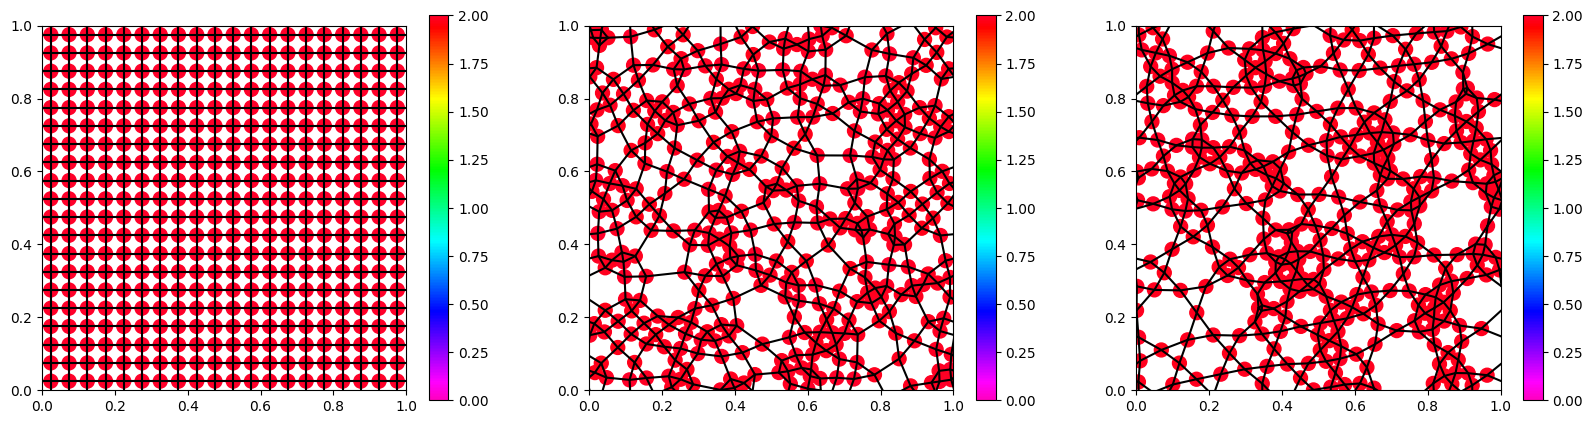

In [187]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

pl.plot_edges(lattice_0, ax=ax[0])
pl.plot_edges(lattice1, ax=ax[1])
pl.plot_edges(lattice2, ax=ax[2])


c0 = ax[0].scatter(
    *lattice_0.vertices.positions.T, c=m0, cmap="gist_rainbow_r", s=100, clim=(0, 2)
)
c1 = ax[1].scatter(
    *lattice1.vertices.positions.T, c=m1, cmap="gist_rainbow_r", s=100, clim=(0, 2)
)
c2 = ax[2].scatter(
    *lattice2.vertices.positions.T, c=m2, cmap="gist_rainbow_r", s=100, clim=(0, 2)
)
# enforce square aspect ratio
for a in ax:
    a.set_aspect("equal")

# colorbars
fig.colorbar(c0, ax=ax[0])
fig.colorbar(c1, ax=ax[1])
fig.colorbar(c2, ax=ax[2])
